<a href="https://colab.research.google.com/github/rirfan3689/CSCI323-Spam-Detection/blob/main/notebooks/13_feature_importance.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import files
import numpy as np
from scipy.sparse import load_npz
import pandas as pd

uploaded = files.upload()  # Upload 6 files:
                           # X_train.npz, y_train.npy
                           # X_test.npz, y_test.npy
                           # spam.csv (for rebuilding TF-IDF)
                           # tuning_results.json

X_train = load_npz('X_train.npz')
X_test = load_npz('X_test.npz')
y_train = np.load('y_train.npy', allow_pickle=True)
y_test = np.load('y_test.npy', allow_pickle=True)

print("Data loaded!")
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

Saving spam.csv to spam.csv
Saving tuning_results.json to tuning_results.json
Saving X_test.npz to X_test.npz
Saving X_train.npz to X_train.npz
Saving y_test.npy to y_test.npy
Saving y_train.npy to y_train.npy
Data loaded!
X_train: (4135, 5000)
X_test: (1034, 5000)


In [2]:
import re
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from sklearn.feature_extraction.text import TfidfVectorizer

stemmer = PorterStemmer()
stop_words = set(stopwords.words('english'))

def preprocess_text(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    tokens = text.split()
    tokens = [stemmer.stem(word) for word in tokens
              if word not in stop_words]
    return ' '.join(tokens)

# Load and preprocess UCI dataset
df = pd.read_csv('spam.csv', encoding='latin-1',
                  sep='\t', header=None,
                  names=['label', 'message'])
df = df.drop_duplicates()
df['cleaned'] = df['message'].apply(preprocess_text)

# Rebuild TF-IDF
tfidf = TfidfVectorizer(max_features=5000)
tfidf.fit(df['cleaned'])
feature_names = tfidf.get_feature_names_out()

print("Feature names extracted:", len(feature_names))
print("Sample features:", feature_names[:10])

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


Feature names extracted: 5000
Sample features: ['aah' 'aberdeen' 'abi' 'abil' 'abiola' 'abj' 'abl' 'abnorm' 'abouta'
 'abroad']


In [3]:
import json
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

# Load tuning results for best parameters
with open('tuning_results.json') as f:
    tuning_results = json.load(f)

print("Best parameters loaded:")
for name, results in tuning_results.items():
    print(f"  {name}: {results['best_params']}")

# Train with best parameters
nb_model = MultinomialNB(alpha=0.1)
lr_model = LogisticRegression(
    max_iter=1000, random_state=42,
    C=10.0, class_weight='balanced')
svm_model = SVC(kernel='linear', random_state=42, C=1.0)
rf_model = RandomForestClassifier(
    random_state=42, n_estimators=200,
    max_depth=None, min_samples_split=5)

nb_model.fit(X_train, y_train)
lr_model.fit(X_train, y_train)
svm_model.fit(X_train, y_train)
rf_model.fit(X_train, y_train)

print("\nAll models trained with best parameters!")

Best parameters loaded:
  Naive Bayes: {'alpha': 0.1}
  Logistic Regression: {'C': 10.0, 'class_weight': 'balanced'}
  SVM: {'C': 1.0}
  Random Forest: {'max_depth': None, 'min_samples_split': 5, 'n_estimators': 200}

All models trained with best parameters!


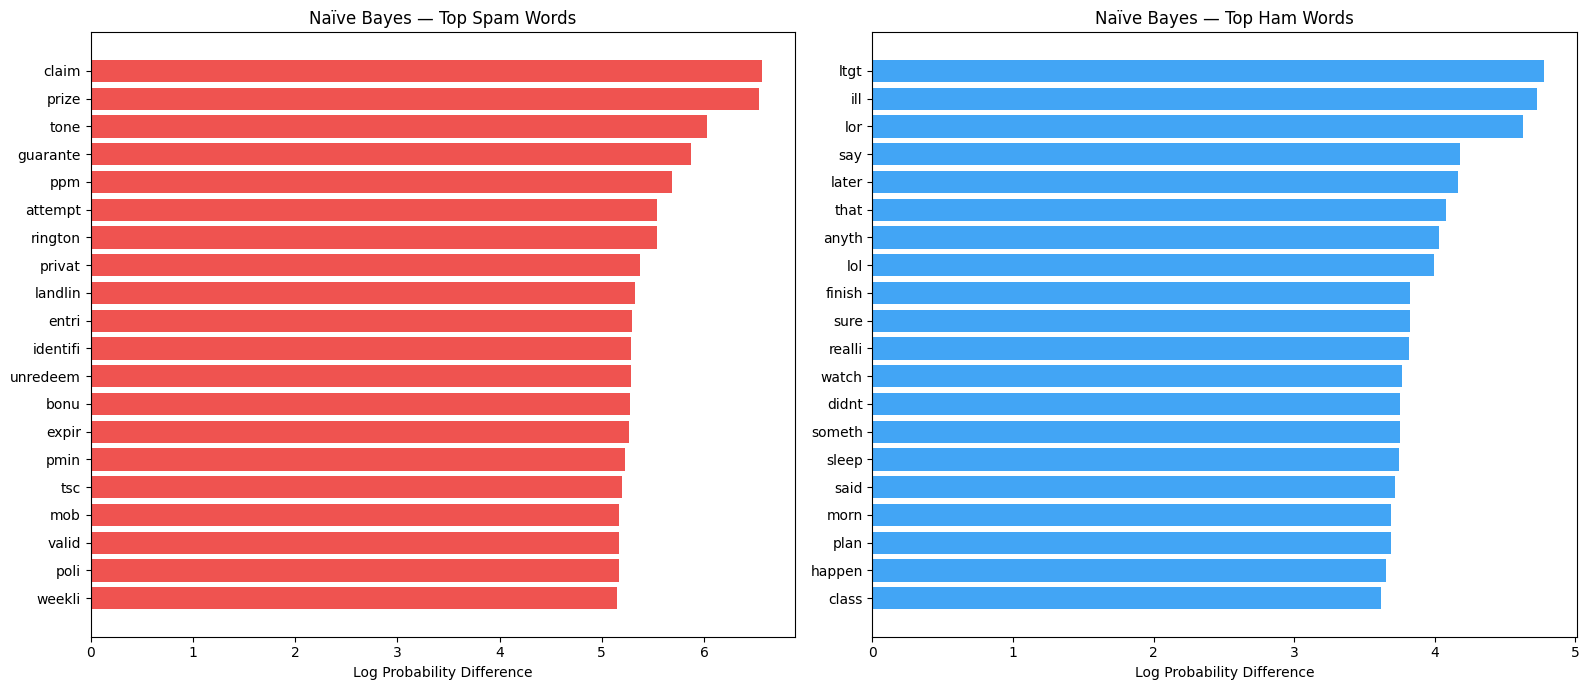

In [4]:
import matplotlib.pyplot as plt

def plot_nb_top_words(model, feature_names, top_n=20):
    spam_idx = list(model.classes_).index('spam')
    ham_idx = list(model.classes_).index('ham')

    diff_scores = (model.feature_log_prob_[spam_idx] -
                   model.feature_log_prob_[ham_idx])

    top_spam_idx = diff_scores.argsort()[-top_n:][::-1]
    top_ham_idx = diff_scores.argsort()[:top_n]

    fig, axes = plt.subplots(1, 2, figsize=(16, 7))

    axes[0].barh(range(top_n),
                 diff_scores[top_spam_idx],
                 color='#EF5350')
    axes[0].set_yticks(range(top_n))
    axes[0].set_yticklabels([feature_names[i]
                              for i in top_spam_idx])
    axes[0].set_title('Naïve Bayes — Top Spam Words')
    axes[0].set_xlabel('Log Probability Difference')
    axes[0].invert_yaxis()

    axes[1].barh(range(top_n),
                 abs(diff_scores[top_ham_idx]),
                 color='#42A5F5')
    axes[1].set_yticks(range(top_n))
    axes[1].set_yticklabels([feature_names[i]
                              for i in top_ham_idx])
    axes[1].set_title('Naïve Bayes — Top Ham Words')
    axes[1].set_xlabel('Log Probability Difference')
    axes[1].invert_yaxis()

    plt.tight_layout()
    plt.savefig('nb_top_words.png')
    plt.show()

plot_nb_top_words(nb_model, feature_names)

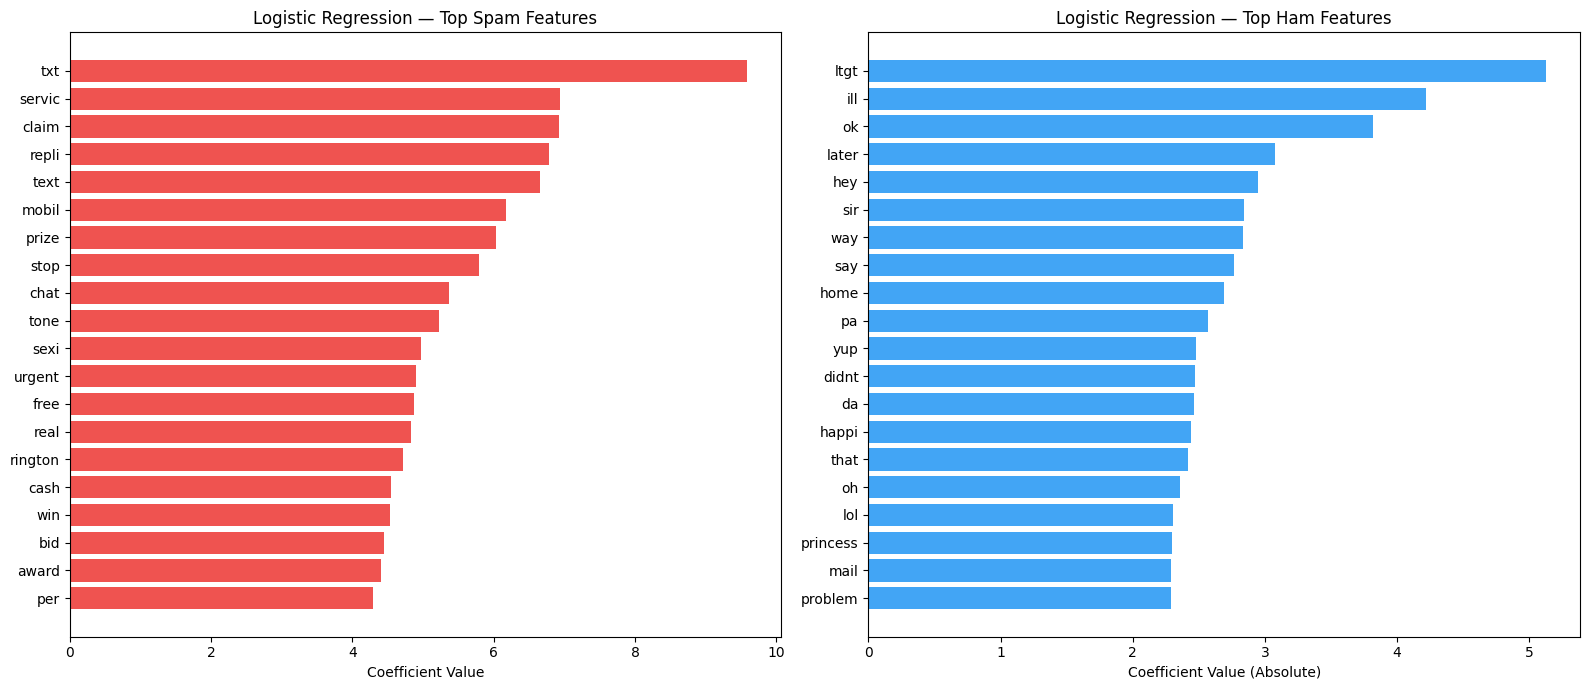

In [5]:
def plot_lr_top_features(model, feature_names, top_n=20):
    coef = model.coef_[0]

    top_spam_idx = coef.argsort()[-top_n:][::-1]
    top_ham_idx = coef.argsort()[:top_n]

    fig, axes = plt.subplots(1, 2, figsize=(16, 7))

    axes[0].barh(range(top_n),
                 coef[top_spam_idx],
                 color='#EF5350')
    axes[0].set_yticks(range(top_n))
    axes[0].set_yticklabels([feature_names[i]
                              for i in top_spam_idx])
    axes[0].set_title('Logistic Regression — Top Spam Features')
    axes[0].set_xlabel('Coefficient Value')
    axes[0].invert_yaxis()

    axes[1].barh(range(top_n),
                 abs(coef[top_ham_idx]),
                 color='#42A5F5')
    axes[1].set_yticks(range(top_n))
    axes[1].set_yticklabels([feature_names[i]
                              for i in top_ham_idx])
    axes[1].set_title('Logistic Regression — Top Ham Features')
    axes[1].set_xlabel('Coefficient Value (Absolute)')
    axes[1].invert_yaxis()

    plt.tight_layout()
    plt.savefig('lr_top_features.png')
    plt.show()

plot_lr_top_features(lr_model, feature_names)

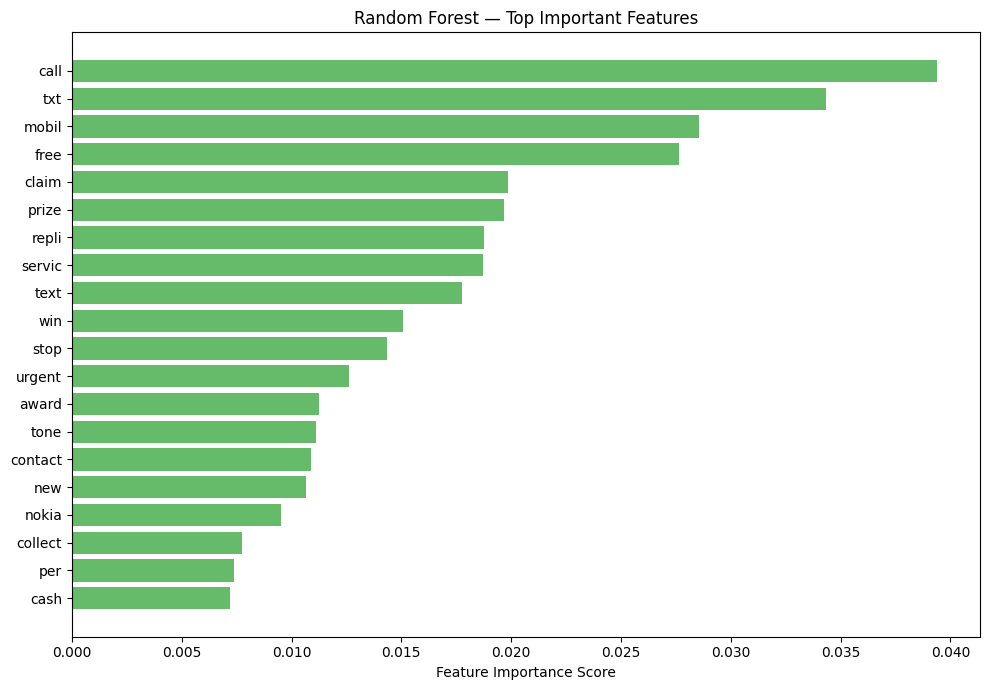

In [6]:
def plot_rf_importance(model, feature_names, top_n=20):
    importances = model.feature_importances_
    top_idx = importances.argsort()[-top_n:][::-1]

    fig, ax = plt.subplots(figsize=(10, 7))
    ax.barh(range(top_n),
            importances[top_idx],
            color='#66BB6A')
    ax.set_yticks(range(top_n))
    ax.set_yticklabels([feature_names[i] for i in top_idx])
    ax.set_title('Random Forest — Top Important Features')
    ax.set_xlabel('Feature Importance Score')
    ax.invert_yaxis()

    plt.tight_layout()
    plt.savefig('rf_importance.png')
    plt.show()

plot_rf_importance(rf_model, feature_names)

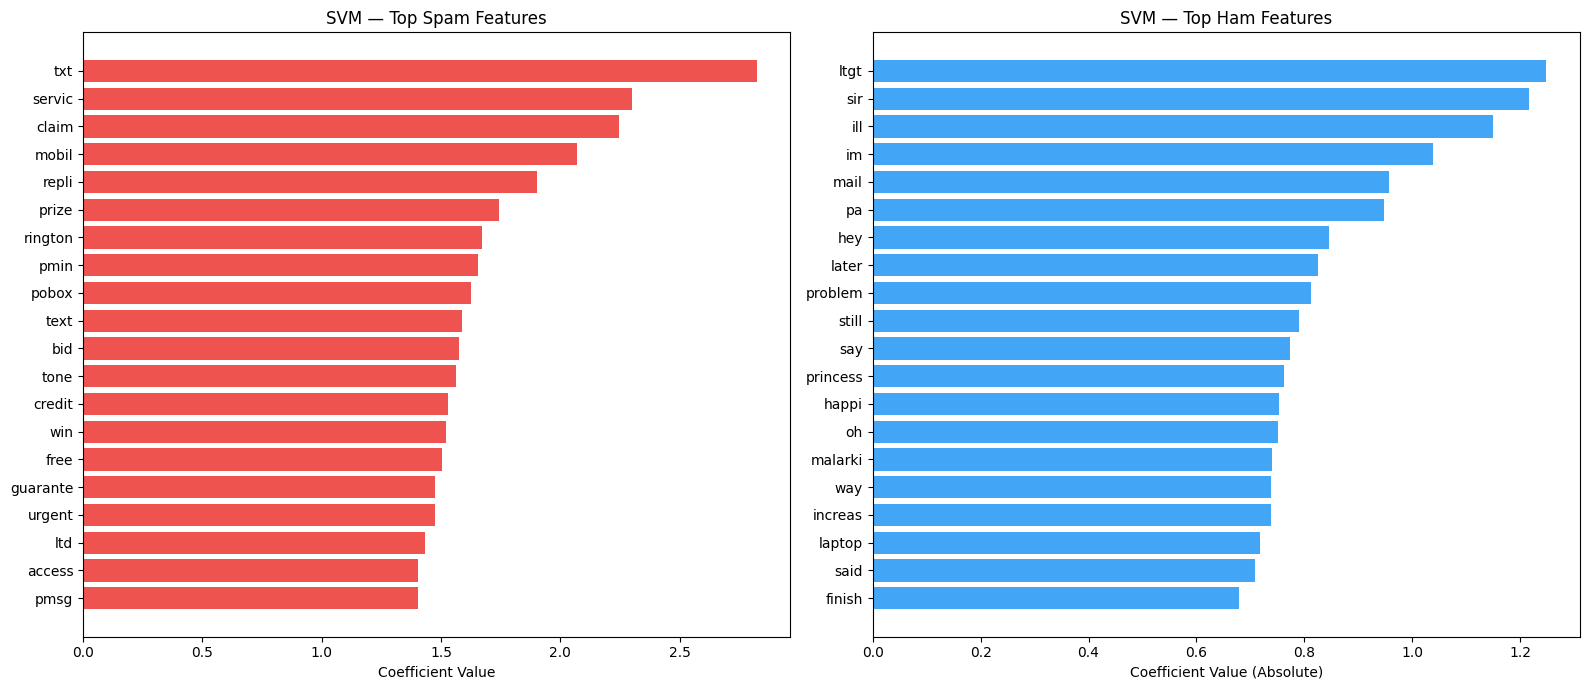

In [7]:
def plot_svm_top_features(model, feature_names, top_n=20):
    coef = model.coef_.toarray()[0]

    top_spam_idx = coef.argsort()[-top_n:][::-1]
    top_ham_idx = coef.argsort()[:top_n]

    fig, axes = plt.subplots(1, 2, figsize=(16, 7))

    axes[0].barh(range(top_n),
                 coef[top_spam_idx],
                 color='#EF5350')
    axes[0].set_yticks(range(top_n))
    axes[0].set_yticklabels([feature_names[i]
                              for i in top_spam_idx])
    axes[0].set_title('SVM — Top Spam Features')
    axes[0].set_xlabel('Coefficient Value')
    axes[0].invert_yaxis()

    axes[1].barh(range(top_n),
                 abs(coef[top_ham_idx]),
                 color='#42A5F5')
    axes[1].set_yticks(range(top_n))
    axes[1].set_yticklabels([feature_names[i]
                              for i in top_ham_idx])
    axes[1].set_title('SVM — Top Ham Features')
    axes[1].set_xlabel('Coefficient Value (Absolute)')
    axes[1].invert_yaxis()

    plt.tight_layout()
    plt.savefig('svm_top_features.png')
    plt.show()

plot_svm_top_features(svm_model, feature_names)

In [8]:
def get_top_spam_words_nb(model, feature_names, top_n=10):
    spam_idx = list(model.classes_).index('spam')
    ham_idx = list(model.classes_).index('ham')
    diff = (model.feature_log_prob_[spam_idx] -
            model.feature_log_prob_[ham_idx])
    return [feature_names[i] for i in diff.argsort()[-top_n:][::-1]]

def get_top_spam_words_lr(model, feature_names, top_n=10):
    coef = model.coef_[0]
    return [feature_names[i] for i in coef.argsort()[-top_n:][::-1]]

def get_top_spam_words_svm(model, feature_names, top_n=10):
    coef = model.coef_.toarray()[0]
    return [feature_names[i] for i in coef.argsort()[-top_n:][::-1]]

def get_top_spam_words_rf(model, feature_names, top_n=10):
    imp = model.feature_importances_
    return [feature_names[i] for i in imp.argsort()[-top_n:][::-1]]

nb_words = get_top_spam_words_nb(nb_model, feature_names)
lr_words = get_top_spam_words_lr(lr_model, feature_names)
svm_words = get_top_spam_words_svm(svm_model, feature_names)
rf_words = get_top_spam_words_rf(rf_model, feature_names)

print("=== Top 10 Spam Words Across Models ===\n")
print(f"{'Rank':<6} {'Naive Bayes':<15} {'Log Reg':<15} {'SVM':<15} {'Random Forest':<15}")
print("-" * 65)
for i in range(10):
    print(f"{i+1:<6} {nb_words[i]:<15} {lr_words[i]:<15} {svm_words[i]:<15} {rf_words[i]:<15}")

# Common words across all models
all_words = set(nb_words) & set(lr_words) & set(svm_words) & set(rf_words)
print(f"\nCommon spam words across ALL models: {all_words if all_words else 'None'}")

# Common across any 3 models
nb_lr = set(nb_words) & set(lr_words)
nb_svm = set(nb_words) & set(svm_words)
lr_svm = set(lr_words) & set(svm_words)
print(f"Common NB & LR: {nb_lr}")
print(f"Common NB & SVM: {nb_svm}")
print(f"Common LR & SVM: {lr_svm}")

=== Top 10 Spam Words Across Models ===

Rank   Naive Bayes     Log Reg         SVM             Random Forest  
-----------------------------------------------------------------
1      claim           txt             txt             call           
2      prize           servic          servic          txt            
3      tone            claim           claim           mobil          
4      guarante        repli           mobil           free           
5      ppm             text            repli           claim          
6      attempt         mobil           prize           prize          
7      rington         prize           rington         repli          
8      privat          stop            pmin            servic         
9      landlin         chat            pobox           text           
10     entri           tone            text            win            

Common spam words across ALL models: {'prize', 'claim'}
Common NB & LR: {'prize', 'claim', 'tone'}
Common NB & 

In [9]:
feature_importance_results = {
    'nb_top_spam_words': nb_words,
    'lr_top_spam_words': lr_words,
    'svm_top_spam_words': svm_words,
    'rf_top_spam_words': rf_words,
    'common_all_models': list(all_words)
}

with open('feature_importance_results.json', 'w') as f:
    json.dump(feature_importance_results, f)

print("Feature importance results saved!")

Feature importance results saved!
